In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
from google.colab import drive
drive.mount('/content/drive')


# The path always starts with /content/drive/MyDrive/
path = '/content/drive/MyDrive/WA_Fn-UseC_-Telco-Customer-Churn.csv'

df = pd.read_csv(path)



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:


# Senior Tip: Always look at the 'shape' to know how much data you have
print(f"Dataset contains {df.shape[0]} rows and {df.shape[1]} columns.\n")

# Display the first 5 rows to see what we are dealing with
df.head()

Dataset contains 7043 rows and 21 columns.



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [11]:
print(df.dtypes)
print(df.info())
print("\nMissing values per column:")
print(df.isnull().sum())


customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Depe

In [12]:
#Convert TotalCharges string to Number
# 1.'coerce' handles any blank spaces by turning them into 'NaN' (Not a Number)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 2. Fill the empty spots with the median value (a safe middle ground)

df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# 3. Drop the customerID column because it has no predictive power

df['customerID'].drop(columns=['customerID'])

# 4. Final check to see if everything is cleaned up
print(df.info())
print("\nMissing values per column:")
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


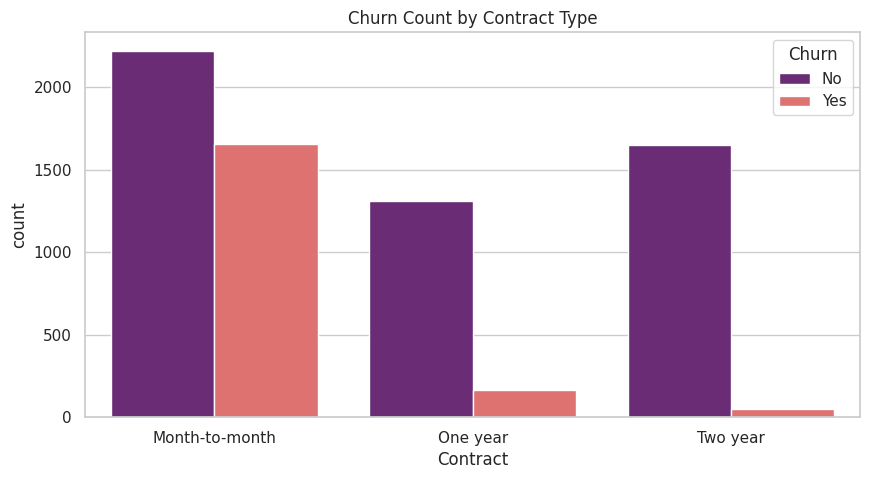

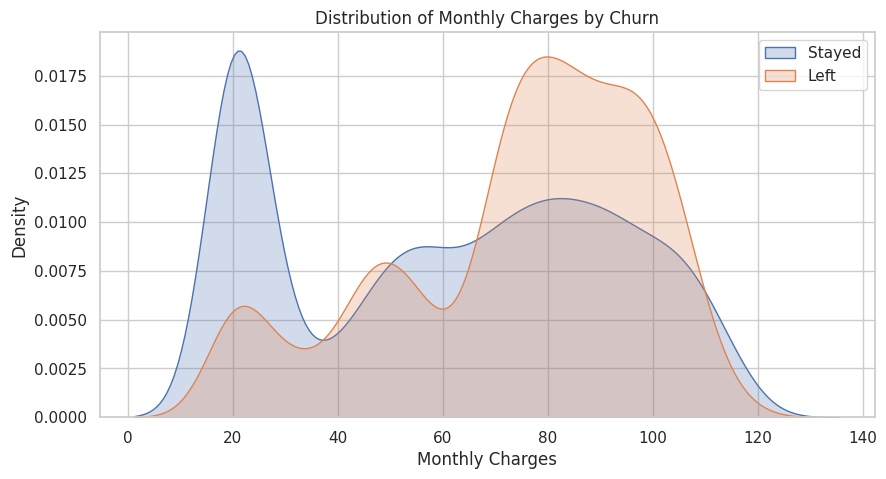

In [13]:

# Set the style for our charts
sns.set_theme(style="whitegrid")

# 1. Let's look at Contract Type vs Churn
plt.figure(figsize=(10, 5))
sns.countplot(x='Contract', hue='Churn', data=df, palette='magma')
plt.title('Churn Count by Contract Type')
plt.show()

# 2. Let's look at Monthly Charges
plt.figure(figsize=(10, 5))
sns.kdeplot(df.MonthlyCharges[df.Churn == 'No'], label='Stayed', fill=True)
sns.kdeplot(df.MonthlyCharges[df.Churn == 'Yes'], label='Left', fill=True)
plt.xlabel('Monthly Charges')
plt.title('Distribution of Monthly Charges by Churn')
plt.legend()
plt.show()

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. PREPARATION: Drop customerID if it's still there and encode
if 'customerID' in df.columns:
    df = df.drop('customerID', axis=1)

# Map Churn to numbers
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# One-Hot Encode the categorical columns
df_final = pd.get_dummies(df)
print(f"Final Data Shape: {df_final.shape}")

# 2. DATA SPLIT: Separate features (X) and target (y)
X = df_final.drop('Churn', axis=1)
y = df_final['Churn']


Final Data Shape: (7043, 46)


In [15]:

df_final.head()


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,True,False,False,True,True,...,False,True,False,False,False,True,False,False,True,False
1,0,34,56.95,1889.50,0,False,True,True,False,True,...,False,False,True,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,False,True,True,False,True,...,False,True,False,False,False,True,False,False,False,True
3,0,45,42.30,1840.75,0,False,True,True,False,True,...,False,False,True,False,True,False,True,False,False,False
4,0,2,70.70,151.65,1,True,False,True,False,True,...,False,True,False,False,False,True,False,False,True,False


In [16]:
# 1. 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Initialize the Model
# n_estimators=100 means we are using 100 'Decision Trees'
model = RandomForestClassifier(n_estimators=100, random_state=42)

# 3. Training: This is where the AI 'learns' the patterns
model.fit(X_train, y_train)

# 4. Testing: Ask the AI to predict churn for the 20% of data it hasn't seen
y_pred = model.predict(X_test)

# 5. Show Results
print(f"Success! The AI is {accuracy_score(y_test, y_pred):.2%} accurate.")


Success! The AI is 79.63% accurate.


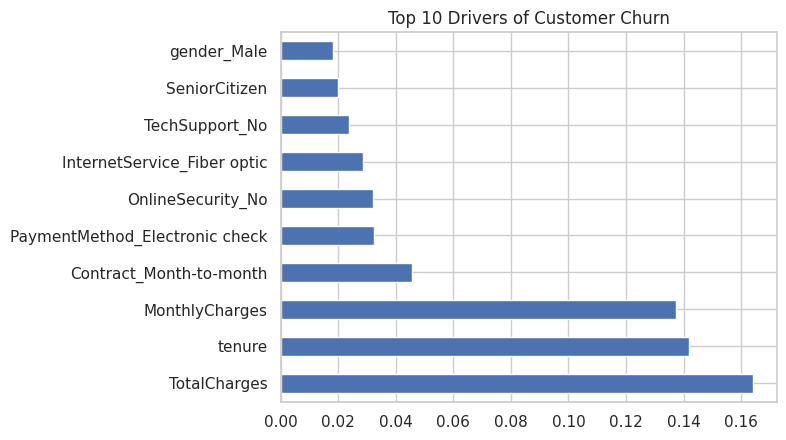

In [17]:
# Pull the importance of each feature from the model
importances = pd.Series(model.feature_importances_, index=X.columns)

# Sort them and look at the Top 10
importances.nlargest(10).plot(kind='barh')
plt.title('Top 10 Drivers of Customer Churn')
plt.show()


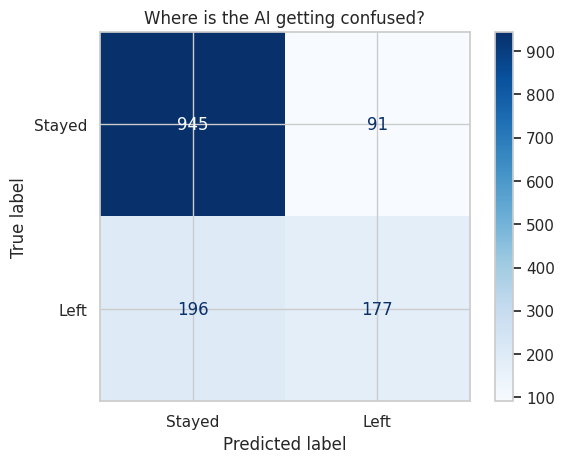

In [18]:
from sklearn.metrics import ConfusionMatrixDisplay

# Create the matrix
cm = confusion_matrix(y_test, y_pred)

# Plot it professionally
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Left'])
disp.plot(cmap='Blues')
plt.title('Where is the AI getting confused?')
plt.show()



In [19]:
import joblib

# 1. Save the model to a file
joblib.dump(model, 'churn_model.pkl')

# 2. Save the column names (you'll need these later to make sure inputs match)
joblib.dump(X.columns, 'model_columns.pkl')

print("Files saved! You can now download 'churn_model.pkl' from the Colab folder icon.")


Files saved! You can now download 'churn_model.pkl' from the Colab folder icon.
